# 4. Beamformers

All common beamformers compare the cross-spectral density matrix $K$ of the recordings with the steering vectors $\mathbf{s}$ of the grid points (notebook 1). They differ in what they do with $K$:

| beamformer | beampower | `method` |
|---|---|---|
| Bartlett | $\mathbf{s}^H K\, \mathbf{s}$ | `"bartlett"` |
| cross-correlation | $\mathbf{s}^H K\, \mathbf{s}$ without the auto-correlations $j = k$ | `"crosscorrelation"` |
| MVDR | $1 / (\mathbf{s}^H K^{-1} \mathbf{s})$ | `"mvdr"` |
| MUSIC | $1 / (\mathbf{s}^H E_n E_n^H \mathbf{s})$, with $E_n$ from the eigenvectors of $K$ | `"music"` |

Each is summed over frequencies. In code, each is the beamformer of notebook 2 with one more step: turn $K$ into the matrix $A$ of the beamformer, then compute $\mathbf{s}^H A\, \mathbf{s}$ for all grid points. We write that first, and then compare the beamformers on recordings with noise:

1. **Adaptive beamformers** (MVDR, MUSIC) separate sources that are close together, but need more data and trust the model more.
2. **Bartlett vs. cross-correlation**: with or without the auto-correlations.
3. **Coherence**: beampower scaled to between 0 and 1.

The array, a function that makes recordings (each source emits a random signal in every time window), and two helpers for the figures:

In [1]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(42)
n_sensors = 30
stations = rng.uniform(-25, 25, size=(n_sensors, 2))
medium_velocity = 3  # km/s

# 100 s windows at 10 Hz
freqs = np.fft.fftfreq(1000, 1 / 10)


def band(fmin, fmax):
    return 2 * np.pi * freqs[(freqs > fmin) & (freqs < fmax)]


def make_recordings(sources, noise_level, n_windows, omega, seed=0):
    """Spectra (n_windows, n_sensors, n_freqs): each source emits a random signal of unit
    amplitude per frequency, recorded with independent noise of the given amplitude."""
    rng = np.random.default_rng(seed)
    spectra = np.zeros((n_windows, n_sensors, len(omega)), dtype=complex)
    for source in sources:
        traveltimes = np.linalg.norm(stations - source, axis=1) / medium_velocity
        signal = np.exp(2j * np.pi * rng.uniform(size=(n_windows, 1, len(omega))))  # random phases
        spectra += signal * np.exp(-1j * omega[None, None, :] * traveltimes[None, :, None])
    noise = rng.normal(size=spectra.shape) + 1j * rng.normal(size=spectra.shape)
    return spectra + noise_level * noise / np.sqrt(2)


def grid(x0, x1, y0, y1, spacing):
    xs, ys = np.arange(x0, x1, spacing), np.arange(y0, y1, spacing)
    xx, yy = np.meshgrid(xs, ys, indexing="ij")
    return xs, ys, np.stack([xx.ravel(), yy.ravel()], axis=1)


def plot_map(ax, xs, ys, values, title, **kwargs):
    pcm = ax.pcolormesh(xs, ys, values.reshape(len(xs), len(ys)).T, shading="nearest", **kwargs)
    ax.scatter(*stations.T, marker="v", s=30, c="#3f90da", ec="k", lw=0.3)
    ax.set(aspect="equal", xlim=(xs[0], xs[-1]), ylim=(ys[0], ys[-1]), xlabel="x [km]", title=title)
    return pcm

## The beamformers in code

The spectra have the shape (windows, sensors, frequencies); $K$ is averaged over the windows. `implementations/` has the same in `pytorch`, `jax`, `cupy` and `numba` (notebook 3).

In [2]:
def matrix(d, method, n_sources=1, diagonal_loading=0.01):
    """A, shape (sensors, sensors), from the spectra d (sensors, windows) of one frequency."""
    K = d @ d.conj().T / d.shape[1]  # cross-spectral density matrix, averaged over windows
    n_sensors = len(K)
    if method == "bartlett":
        return K
    if method == "crosscorrelation":
        return K - np.diag(np.diag(K))  # leave out the auto-correlations
    if method == "mvdr":
        loading = diagonal_loading * np.trace(K).real / n_sensors
        return np.linalg.inv(K + loading * np.eye(n_sensors))
    if method == "music":
        signal = np.linalg.eigh(K)[1][:, -n_sources:]  # eigenvectors of the largest eigenvalues
        return np.eye(n_sensors) - signal @ signal.conj().T  # E_n E_n^H = 1 - E_s E_s^H


def beamform(spectra, omega, stations, gridpoints, medium_velocity, method="crosscorrelation", **options):
    """One value per grid point, from spectra of shape (windows, sensors, frequencies)."""
    traveltimes = (
        np.linalg.norm(np.asarray(gridpoints)[:, None, :] - stations[None, :, :], axis=2) / medium_velocity
    )
    adaptive = method in ("mvdr", "music")
    output = np.zeros(len(traveltimes))
    for w in range(len(omega)):
        A = matrix(spectra[:, :, w].T, method, **options)
        s = np.exp(-1j * omega[w] * traveltimes)  # steering vectors, (grid points, sensors)
        q = np.sum((s.conj() @ A) * s, axis=1).real  # s^H A s
        output += 1 / q if adaptive else q
    return output / len(omega) if adaptive else output


METHODS = {
    "cross-correlation": dict(method="crosscorrelation"),
    "MVDR": dict(method="mvdr"),
    "MUSIC": dict(method="music", n_sources=2),
}
COLORS = {"cross-correlation": "#3f90da", "MVDR": "#ffa90e", "MUSIC": "#bd1f01"}

## 1. Adaptive beamformers: MVDR and MUSIC

Conventional beamformers use the cross-spectral density matrix (CSDM) $K$ as it is. Two sources closer than about a wavelength merge into one peak. *Adaptive* beamformers first process $K$, averaged over many time windows, to sharpen the peaks.

**MVDR** (or Capon) uses the inverse of $K$: $P_\text{MVDR}(\mathbf{x}) = 1 / (s^H K^{-1} s)$. A small "diagonal loading", $K + \epsilon I$, keeps the inverse stable (`diagonal_loading`).

**MUSIC** splits the eigenvectors of $K$ into those of the strongest sources (`n_sources`) and the rest, the *noise subspace* $E_n$. At a true source, $s$ is orthogonal to the noise subspace, so $P_\text{MUSIC}(\mathbf{x}) = 1 / (s^H E_n E_n^H s)$ has a sharp peak.

We place two sources 4 km apart inside the array, and use 0.1–0.3 Hz (wavelengths of 10–30 km).

spectra: (100, 30, 19) (windows, sensors, frequencies)


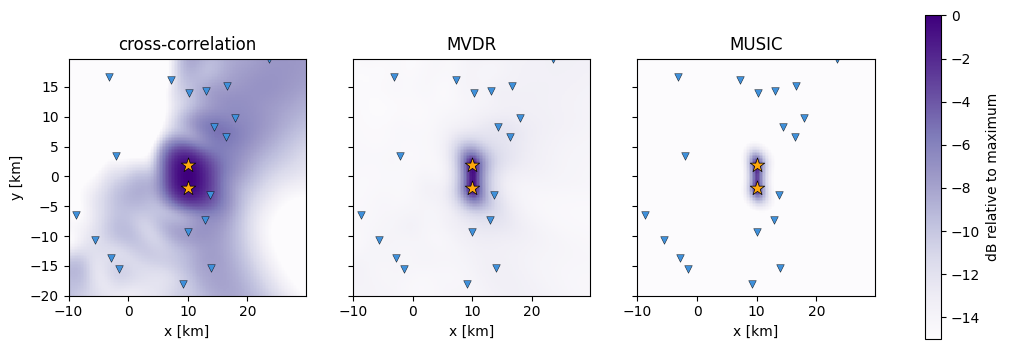

In [3]:
sources = np.array([[10.0, -2.0], [10.0, 2.0]])
omega_low = band(0.1, 0.3)
spectra_two = make_recordings(sources, noise_level=1.0, n_windows=100, omega=omega_low, seed=2)
print(f"spectra: {spectra_two.shape} (windows, sensors, frequencies)")

xs, ys, zoom = grid(-10, 30, -20, 20, 0.25)
outputs = {
    name: beamform(spectra_two, omega_low, stations, zoom, medium_velocity, **kwargs)
    for name, kwargs in METHODS.items()
}

fig, axs = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, (name, output) in zip(axs, outputs.items()):
    image = 10 * np.log10(np.clip(output / output.max(), 1e-3, None))
    pcm = plot_map(ax, xs, ys, image, name, cmap="Purples", vmin=-15, vmax=0)
    ax.scatter(*sources.T, marker="*", s=120, c="#ffa90e", ec="k", lw=0.5)
axs[0].set_ylabel("y [km]")
fig.colorbar(pcm, ax=axs, label="dB relative to maximum")

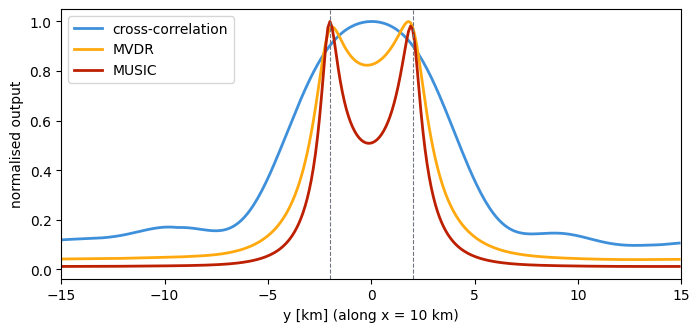

In [4]:
profile_y = np.arange(-15, 15, 0.1)
profile = np.stack([np.full_like(profile_y, 10.0), profile_y], axis=1)


def resolve(spectra, omega=omega_low, velocity=medium_velocity, **kwargs):
    """Output along the line through both sources, normalised to its maximum."""
    output = beamform(spectra, omega, stations, profile, velocity, **kwargs)
    return output / output.max()


fig, ax = plt.subplots(figsize=(8, 3.5))
for name, kwargs in METHODS.items():
    ax.plot(profile_y, resolve(spectra_two, **kwargs), lw=2, c=COLORS[name], label=name)
for y in sources[:, 1]:
    ax.axvline(y, color="#717581", lw=0.8, ls="--")
ax.set(xlabel="y [km] (along x = 10 km)", ylabel="normalised output", xlim=(-15, 15))
ax.legend(loc="upper left")

The cross-correlation beamformer merges the two sources into one peak. MVDR separates them, MUSIC most clearly. This has a price.

### How many time windows?

Adaptive beamformers estimate $K$ from the data, so they need it averaged over many windows, ideally more windows than sensors (here 30). We measure how well the sources are separated by the dip between them: the output midway, relative to the output at the sources. Below 1, they are separated.

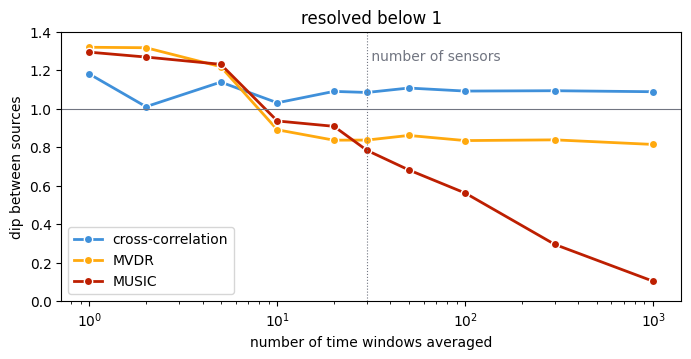

In [5]:
def dip(output):
    """Output midway between the sources relative to the output at the sources."""
    at = lambda y: output[np.argmin(np.abs(profile_y - y))]  # noqa: E731
    return at(0.0) / np.mean([at(y) for y in sources[:, 1]])


window_counts = [1, 2, 5, 10, 20, 30, 50, 100, 300, 1000]
dips = {name: [] for name in METHODS}
for n_windows in window_counts:
    spectra = make_recordings(sources, noise_level=1.0, n_windows=n_windows, omega=omega_low, seed=3)
    for name, kwargs in METHODS.items():
        dips[name].append(dip(resolve(spectra, **kwargs)))

fig, ax = plt.subplots(figsize=(8, 3.5))
for name in METHODS:
    ax.plot(window_counts, dips[name], "o-", lw=2, ms=6, mec="w", c=COLORS[name], label=name)
ax.axhline(1, color="#717581", lw=0.8)
ax.axvline(n_sensors, color="#717581", lw=0.8, ls=":")
ax.text(n_sensors, 1.25, " number of sensors", color="#717581")
ax.set(xscale="log", xlabel="number of time windows averaged", ylabel="dip between sources", ylim=(0, 1.4))
ax.set_title("resolved below 1")
ax.legend(loc="lower left")

The cross-correlation beamformer never separates them: its resolution is set by the wavelength and the size of the array, not by noise. MVDR separates them from about 10 windows on. MUSIC keeps improving with more windows.

**A single window is not enough.** Then $K = \mathbf{d}\mathbf{d}^H$ holds one vector, and MVDR and MUSIC are only the Bartlett map $b = \mathbf{s}^H K\, \mathbf{s}$ drawn on another scale: $\epsilon / (n - b / (\epsilon + |\mathbf{d}|^2))$ for MVDR with loading $\epsilon$, and $1 / (n - b / |\mathbf{d}|^2)$ for MUSIC with one source. The peak looks sharper, but two sources stay merged. To separate $m$ sources, $K$ must hold at least $m$ independent windows.

**For results over time** (as in notebook 5), estimate one $K$ per time step from several windows: cut each time step into shorter windows, or average over neighbouring time steps. Shorter windows have fewer frequencies; that is the trade.

### Diagonal loading

More loading makes MVDR more stable, but less sharp. With a lot of loading, it becomes the conventional beamformer:

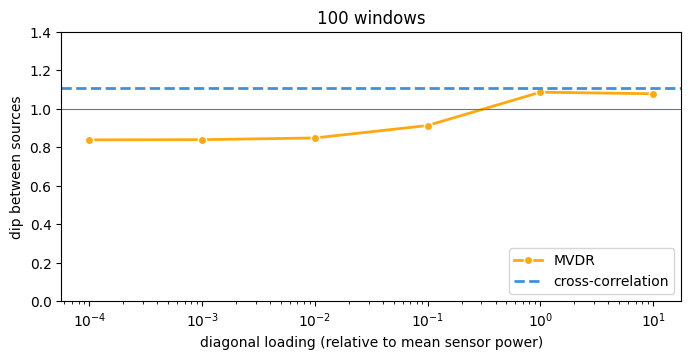

In [6]:
loadings = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
mvdr_dips = [dip(resolve(spectra_two, method="mvdr", diagonal_loading=e)) for e in loadings]
conventional_dip = dip(resolve(spectra_two, method="crosscorrelation"))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(loadings, mvdr_dips, "o-", lw=2, ms=6, mec="w", c=COLORS["MVDR"], label="MVDR")
ax.axhline(conventional_dip, color=COLORS["cross-correlation"], lw=2, ls="--", label="cross-correlation")
ax.axhline(1, color="#717581", lw=0.8)
ax.set(xscale="log", xlabel="diagonal loading (relative to mean sensor power)", ylabel="dip between sources")
ax.set(ylim=(0, 1.4), title="100 windows")
ax.legend(loc="lower right")

### Errors in the model

Adaptive beamformers trust the model. Here, we beamform one source with a velocity that is a few percent off, and compare the peak with the peak for the correct velocity:

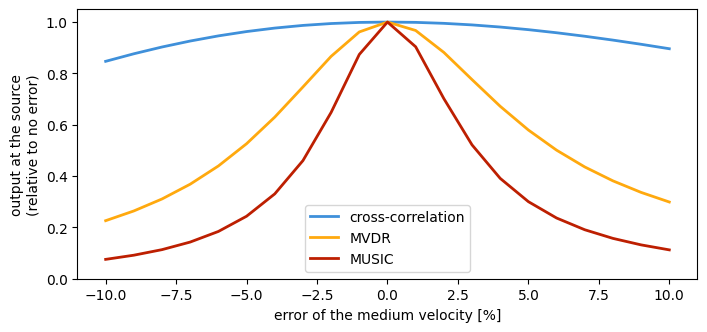

In [7]:
single = make_recordings([np.array([10.0, 0.0])], noise_level=1.0, n_windows=100, omega=omega_low, seed=4)
errors = np.arange(-10, 10.5, 1)
fig, ax = plt.subplots(figsize=(8, 3.5))
for name, kwargs in METHODS.items():
    kwargs = kwargs | ({"n_sources": 1} if name == "MUSIC" else {})
    peaks = np.array([
        beamform(single, omega_low, stations, [[10.0, 0.0]], medium_velocity * (1 + e / 100), **kwargs)[0]
        for e in errors
    ])  # fmt: skip
    ax.plot(errors, peaks / peaks[errors == 0], lw=2, c=COLORS[name], label=name)
ax.set(xlabel="error of the medium velocity [%]", ylabel="output at the source\n(relative to no error)")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower center")

With a 5 % error in the velocity, the cross-correlation beamformer keeps 97 % of its peak, MVDR about 55 %, MUSIC about 30 %. With field data, velocities and positions are never exact, so adaptive beamformers can miss or split real sources.

### Summary

| | separates close sources | robust to model errors | needs |
|---|---|---|---|
| cross-correlation | no | yes | one window |
| MVDR | better | less | many windows |
| MUSIC | best | least | many windows and the number of sources |

For many sensors, MVDR and MUSIC are also expensive: they need $n_\text{sensors}^2$ numbers per frequency (1.6 GB for 10 000 sensors), and the inverse or the eigenvectors of $K$.

## 2. Bartlett vs. cross-correlation

The **Bartlett** beamformer keeps the auto-correlations $j = k$; the **cross-correlation** beamformer leaves them out. The two differ by the recorded energy, which is the same for every grid point:

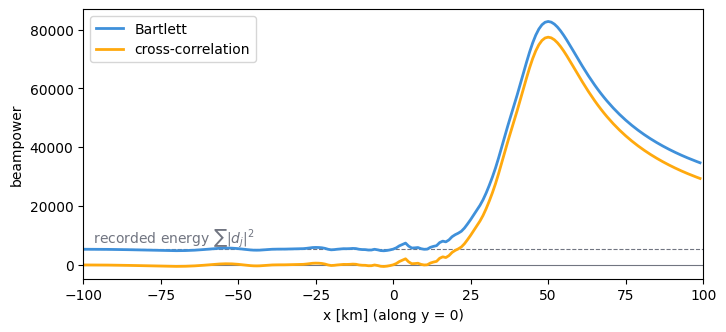

In [8]:
omega = band(0.1, 1.0)
source = np.array([50.0, 0.0])
spectra = make_recordings([source], noise_level=1.0, n_windows=100, omega=omega)
line = np.stack([np.arange(-100, 100, 1.0), np.zeros(200)], axis=1)  # y = 0, through the source

bartlett = beamform(spectra, omega, stations, line, medium_velocity, method="bartlett")
crosscorrelation = beamform(spectra, omega, stations, line, medium_velocity, method="crosscorrelation")
energy = np.sum(np.abs(spectra) ** 2) / len(spectra)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.axhline(0, color="#717581", lw=0.8)
ax.axhline(energy, color="#717581", lw=0.8, ls="--")
ax.text(-98, energy, " recorded energy $\\sum|d_j|^2$", va="bottom", color="#717581")
ax.plot(line[:, 0], bartlett, lw=2, c="#3f90da", label="Bartlett")
ax.plot(line[:, 0], crosscorrelation, lw=2, c="#ffa90e", label="cross-correlation")
ax.set(xlabel="x [km] (along y = 0)", ylabel="beampower", xlim=(-100, 100))
ax.legend(loc="upper left")

- **Bartlett** is always positive. Its baseline is the recorded energy, of signal and noise.
- **Cross-correlation** is around 0 where nothing correlates; negative values mean anti-correlation.

(If the synthetics include amplitudes, e.g. geometric spreading, the auto-correlations differ between grid points and leave an imprint on the Bartlett map.)

## 3. Coherence

Beampower grows with the amplitude of the recordings, so its values cannot be compared between days or arrays. We divide it by its largest possible value. This turns it into a **coherence** between 0 and 1 (here for cross-correlation):

$C(\mathbf{x}) = \frac{\sum_\omega |\sum_j d_j s_j^*|^2 - \sum_\omega \sum_j |d_j|^2}{(n_\text{sensors} - 1) \sum_\omega \sum_j |d_j|^2}.$

For a source of amplitude $a$ recorded with noise of amplitude $\sigma$, the coherence at the source is

$C = \frac{a^2}{a^2 + \sigma^2},$

the **fraction of the recorded energy that comes from the source**. It is 1 without noise. With noise as strong as the signal, half of the energy is noise, and the coherence is 0.5:

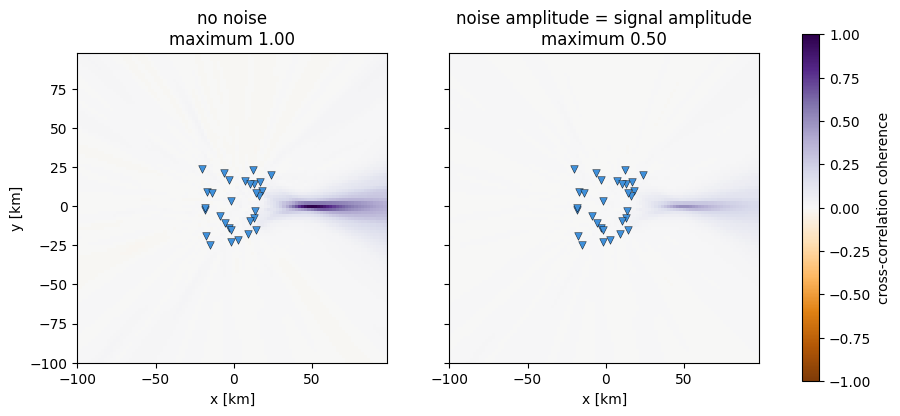

In [9]:
def coherence_of(spectra, omega, gridpoints, method="crosscorrelation"):
    """Beampower divided by its largest possible value, for Bartlett or cross-correlation."""
    beampower = beamform(spectra, omega, stations, gridpoints, medium_velocity, method)
    energy = np.sum(np.abs(spectra) ** 2) / len(spectra)  # recorded energy, averaged over windows
    return beampower / ((n_sensors if method == "bartlett" else n_sensors - 1) * energy)


xs, ys, gridpoints = grid(-100, 100, -100, 100, 2.0)
noise_free = make_recordings([source], noise_level=0.0, n_windows=100, omega=omega)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (data, title) in zip(
    axs, [(noise_free, "no noise"), (spectra, "noise amplitude = signal amplitude")]
):
    coherence = coherence_of(data, omega, gridpoints)
    pcm = plot_map(
        ax, xs, ys, coherence, f"{title}\nmaximum {coherence.max():.2f}", cmap="PuOr", vmin=-1, vmax=1
    )
axs[0].set_ylabel("y [km]")
fig.colorbar(pcm, ax=axs, label="cross-correlation coherence")

Over a range of noise levels, measurement and formula agree:

Text(0.5, 1.0, 'markers: measured, lines: theory')

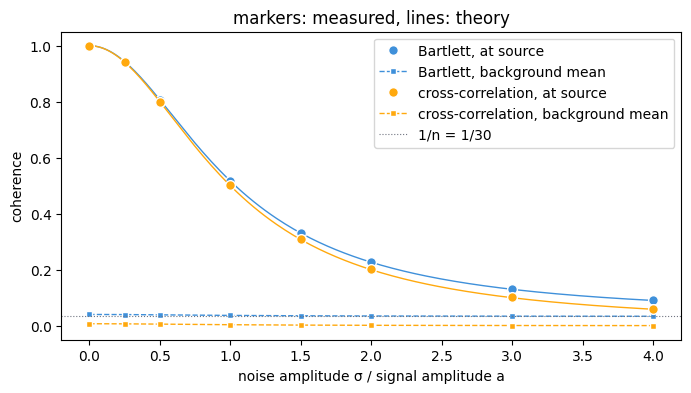

In [10]:
source_idx = np.argmin(np.linalg.norm(gridpoints - source, axis=1))
background = np.linalg.norm(gridpoints - source, axis=1) > 30
noise_levels = np.array([0, 0.25, 0.5, 1, 1.5, 2, 3, 4])
results = {name: {"source": [], "background": []} for name in ["bartlett", "crosscorrelation"]}
for noise_level in noise_levels:
    noisy = make_recordings([source], noise_level=noise_level, n_windows=100, omega=omega, seed=1)
    for name in results:
        coherence = coherence_of(noisy, omega, gridpoints, method=name)
        results[name]["source"].append(coherence[source_idx])
        results[name]["background"].append(coherence[background].mean())

sigma = np.linspace(0, 4, 200)
theory = {"crosscorrelation": 1 / (1 + sigma**2), "bartlett": (1 + sigma**2 / n_sensors) / (1 + sigma**2)}
colors = {"bartlett": "#3f90da", "crosscorrelation": "#ffa90e"}
labels = {"bartlett": "Bartlett", "crosscorrelation": "cross-correlation"}

fig, ax = plt.subplots(figsize=(8, 4))
for name in results:
    ax.plot(sigma, theory[name], lw=1, c=colors[name])
    ax.plot(
        noise_levels,
        results[name]["source"],
        "o",
        ms=7,
        c=colors[name],
        mec="w",
        label=f"{labels[name]}, at source",
    )
    ax.plot(noise_levels, results[name]["background"], "s--", ms=5, lw=1, c=colors[name], mec="w",
            label=f"{labels[name]}, background mean")  # fmt: skip
ax.axhline(1 / n_sensors, color="#717581", lw=0.8, ls=":", label=f"1/n = 1/{n_sensors}")
ax.set(xlabel="noise amplitude σ / signal amplitude a", ylabel="coherence", ylim=(-0.05, 1.05))
ax.legend()
ax.set_title("markers: measured, lines: theory")

Away from the source, the cross-correlation coherence is 0. With the auto-correlations (Bartlett), it never drops below $1/n_\text{sensors}$.

The coherence also stays below 1 if the recordings have different amplitudes, if the source lies between grid points or the model is not exact, or if several sources share the energy.